#### Implement a Kohonen Self-Organizing Map (SOM) to perform unsupervised clustering on a high-dimensional synthetic dataset. The objective is to: 
- Reduce the dimensionality of the dataset while preserving the topological relationships between the data points.
- Discover natural clusters within the data without relying on predefined labels.
- Visualize the clustering results by mapping similar data points to adjacent neurons in the 2D SOM grid.
Dataset Generation:
Generate a synthetic daset with the following characteristics:
-  Number of samples 1000:-  Number of feature 5 (high-dimensional space)
- 
 Number of clusters following characteristicst

In [1]:
%pip install minisom

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')

In [3]:
data, target = make_blobs(n_samples=1000, n_features=5, centers=3, cluster_std=1.0, random_state=42)

In [4]:
data

array([[-1.785584  , 11.31469621,  5.7153119 ,  0.0739933 , -6.80119779],
       [-6.92580982, -9.60331971,  9.35215184,  2.98077676,  3.06504907],
       [-5.06016074, -7.88572936,  7.79721605,  2.54537924,  5.49231874],
       ...,
       [-3.12664424,  7.10218297,  5.0367175 ,  3.48768725, -6.106544  ],
       [-2.46706354,  9.52887512,  5.84451391,  2.82452395, -7.49999091],
       [-3.74701857,  9.53864888,  3.90496842,  1.61906204, -6.42608936]])

In [5]:
target

array([0, 1, 1, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 2, 1, 1, 0, 0, 0, 1,
       1, 2, 0, 2, 1, 2, 1, 0, 2, 2, 0, 0, 2, 0, 2, 1, 2, 0, 0, 2, 0, 2,
       1, 2, 0, 1, 1, 1, 0, 2, 0, 0, 2, 2, 2, 0, 1, 1, 0, 1, 0, 1, 2, 1,
       0, 1, 2, 1, 1, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 0, 2, 2, 2,
       1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 2,
       2, 1, 2, 2, 0, 1, 1, 2, 2, 0, 1, 1, 0, 2, 0, 2, 1, 0, 2, 2, 2, 0,
       0, 0, 2, 2, 0, 1, 1, 2, 0, 0, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 0,
       2, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0,
       1, 0, 2, 0, 1, 0, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 2, 0, 1, 0, 0, 1, 1, 2, 2, 0, 2, 2, 2, 1, 2, 0, 0, 1, 0, 2,
       1, 0, 0, 1, 0, 2, 2, 1, 0, 1, 2, 2, 1, 2, 1, 2, 2, 1, 0, 0, 0, 2,
       2, 1, 1, 1, 0, 1, 2, 0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 2, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 2, 0, 2, 2, 0, 2, 1, 1, 1,

In [6]:
scaler = MinMaxScaler()

In [7]:
data_normalized = scaler.fit_transform(data)

In [8]:
data_normalized

array([[0.7974777 , 0.97186761, 0.47093156, 0.6405105 , 0.17466253],
       [0.40444823, 0.07124519, 0.91590545, 0.84907441, 0.78202005],
       [0.54709859, 0.14519581, 0.72565627, 0.81783431, 0.93144064],
       ...,
       [0.6949382 , 0.79049841, 0.38790432, 0.88544562, 0.21742481],
       [0.74537074, 0.89497932, 0.48673966, 0.83786315, 0.13164544],
       [0.64750343, 0.89540013, 0.24943279, 0.75137035, 0.19775388]])

In [9]:
som_grid_rows = 10
som_grid_cols = 10
som = MiniSom(som_grid_rows, som_grid_cols, 5, sigma=1.5, learning_rate=0.5)

In [10]:
som.pca_weights_init(data_normalized)

In [11]:
som.train_random(data_normalized, 1000)

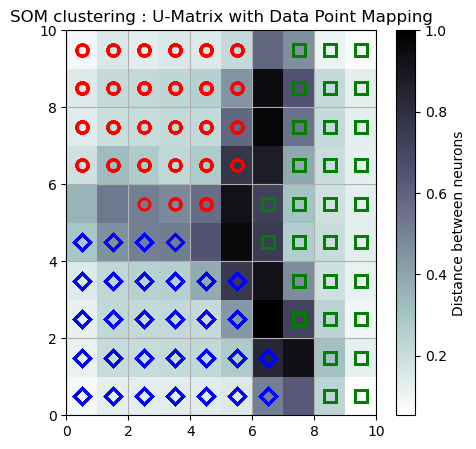

In [12]:
plt.figure(figsize=(5,5))

plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance between neurons')

markers = ['o', 's', 'D']
colors = ['r', 'g', 'b']

for i, x in enumerate(data_normalized):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, markers[target[i]],
        markerfacecolor = 'None', markeredgecolor = colors[target[i]],
        markersize=8, markeredgewidth=2)

plt.title('SOM clustering : U-Matrix with Data Point Mapping')
plt.grid(True)
plt.show()